In [1]:
## IMPORTS ##
import numpy as np
from pathlib import Path
import yt
import matplotlib.pyplot as plt
import sys
import pwlf
sys.path.append("../FLASH")

%load_ext autoreload
%autoreload 2

from fitting_functions import Ray 

yt : [INFO     ] 2026-05-15 23:20:38,162 Loading plugins from /global/homes/d/dschnei/.config/yt/my_plugins.py
yt : [WARNING  ] 2026-05-15 23:20:38,165 Field ('flash', 'idens') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-15 23:20:38,166 Field ('flash', 'edens') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-15 23:20:38,166 Field ('flash', 'Ex') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-15 23:20:38,167 Field ('flash', 'Ey') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-05-15 23:20:38,167 Field ('flash', 'Ez') already exists. To override use `force_override=True`.
yt : [INFO     ] 2026-05-15 23:20:38,309 Parameters: current_time              = 2.5001710269536157e-09
yt : [INFO     ] 2026-05-15 23:20:38,310 Parameters: domain_dimensions         = [60 60 60]
yt : [INFO     ] 2026-05-15 23:20:38,311 Parameters: domain_left_edge          = [-0.85 -0.1  -0.

plasma frequency is 1.26e+14 1/s rad/s for reference density 5.00e+18 cm**(-3) cm^-3
Test magnetic field normalization: 100000 G normalizes to 0.01 dimensionless in OSIRIS units
Corresponding to 99918.57267052571 dimensionless/s Gauss in real units
corresponding to 99890.08749403292 dimensionless/cm**(3/2) Gauss in real units


yt : [INFO     ] 2026-05-15 23:20:50,945 xlim = -0.850000 0.850000
yt : [INFO     ] 2026-05-15 23:20:50,946 ylim = -0.100000 1.600000
yt : [INFO     ] 2026-05-15 23:20:50,949 xlim = -0.850000 0.850000
yt : [INFO     ] 2026-05-15 23:20:50,949 ylim = -0.100000 1.600000
yt : [INFO     ] 2026-05-15 23:20:50,951 Making a fixed resolution buffer of (('flash', 'magz')) 800 by 800



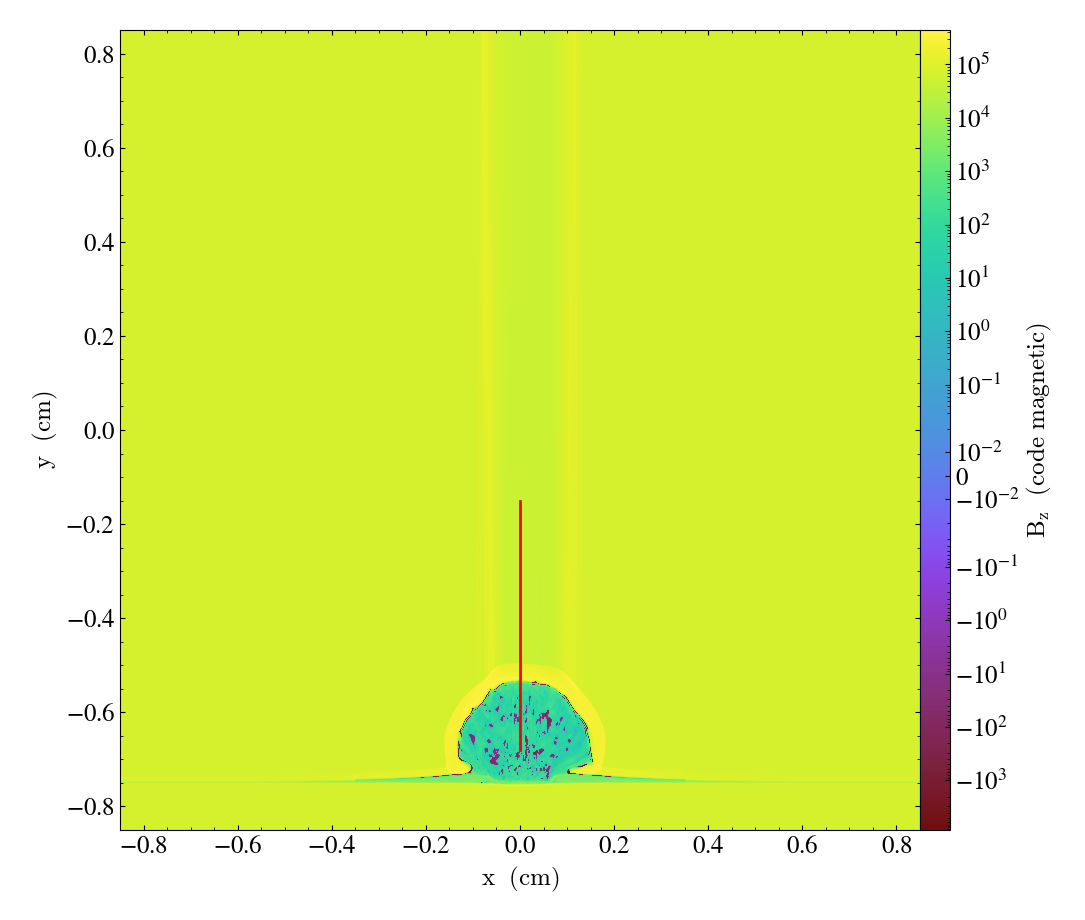

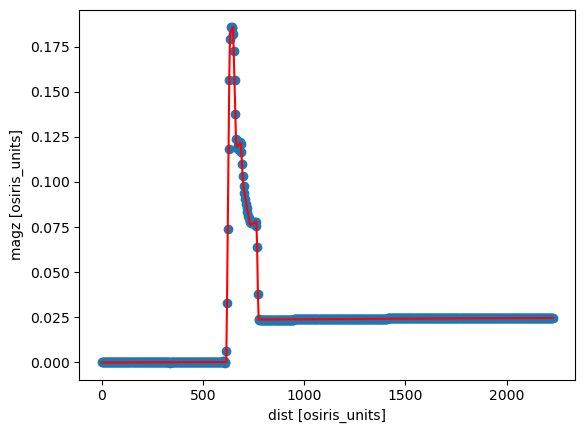

In [23]:
## Path to FLASH data. This data was chosen because it's generally a simple setup.
## We want to characterize the fundamental behavior of a pison expanding out into a magnetized background. 
t = 9
data_path = Path(f"/pscratch/sd/d/dschnei/FLASH_3D_noshield/MagShockZ_hdf5_plt_cnt_{t:04d}")

# Use the plugin I built for yt to load in FLASH data and split up ion species.
yt.enable_plugins()

ds = yt.load_for_osiris(data_path)

start_point = (0,0.07,0)
end_point = (0,0.6,0)

lineout = Ray(ds, start_point, end_point)

lineout.show_ray("magz")

fit_result = lineout.fit("magz", degree=10, fit_func="piecewise", plot=True)

suggest using fit_density for initializing density fields
suggest using fit_density for initializing density fields
suggest using fit_density for initializing density fields


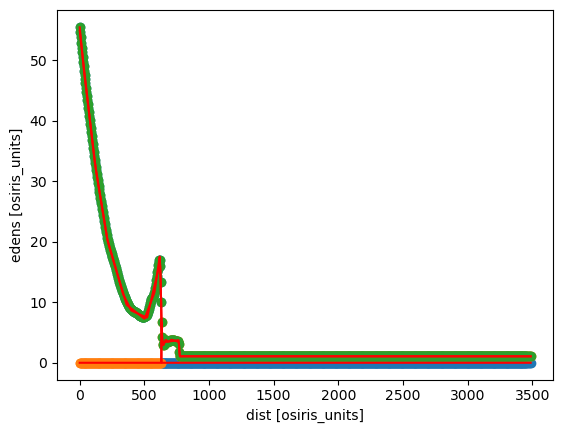

In [5]:
sidens = lineout.fit("sidens", degree=10, fit_func="piecewise", plot=True)
aldens = lineout.fit("aldens", degree=10, fit_func="piecewise", plot=True)
edens = lineout.fit("edens", degree=10, fit_func="piecewise", plot=True)


0., 56.25, 112.49, 168.74, 224.98, 281.23, 337.47, 393.72, 449.96, 506.21, 562.45, 618.70, 674.95, 731.19, 787.44, 843.68, 899.93, 956.17, 1012.42, 1068.66, 1124.91, 1181.16, 1237.40, 1293.65, 1349.89, 1406.14, 1462.38, 1518.63, 1574.87, 1631.12, 1687.36, 1743.61, 1799.86, 1856.10, 1912.35, 1968.59, 2024.84, 2081.08, 2137.33, 2193.57, 2249.82, 2306.06, 2362.31, 2418.56, 2474.80, 2531.05, 2587.29, 2643.54, 2699.78, 2756.03, 2812.27, 2868.52, 2924.77, 2981.01, 3037.26, 3093.50, 3149.75, 3205.99, 3262.24, 3318.48, 3374.73
55.52, 44.13, 34.2, 26.34, 19.59, 15.63, 11.47, 9.02, 8.11, 7.66, 10.67, 17.01, 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.


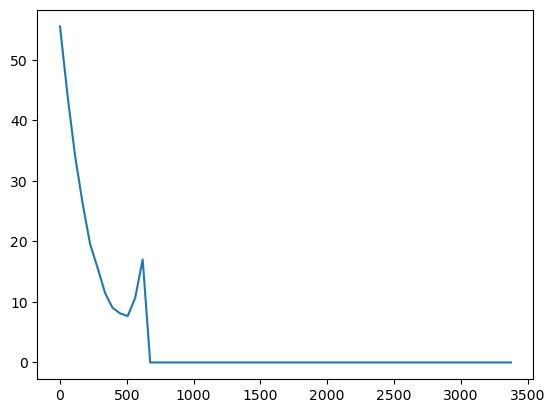

In [10]:
x, sidens = lineout.fit_density("sidens", plot=True)
print(x)
print(sidens)


'if(x2 < 2.5390e+02, x2*(2.7824e-05) + (1.3315e-02), if(x2 < 5.0838e+02, x2*(1.8076e-05) + (1.5790e-02), if(x2 < 7.6902e+02, x2*(-3.4867e-05) + (4.2705e-02), if(x2 < 7.7476e+02, x2*(-2.7082e-03) + (2.0985e+00), if(x2 < 3.4872e+03, x2*(-9.6943e-08) + (4.2965e-04), 0.000429650437661597)))))'

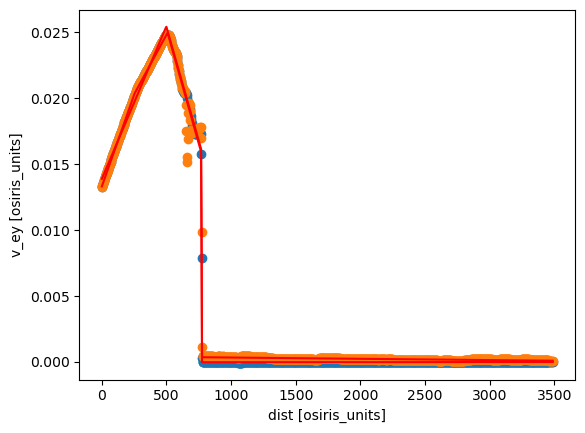

In [12]:
lineout.fit('v_iy', degree=5, fit_func="piecewise", plot=True)
lineout.fit('v_ey', degree=5, fit_func="piecewise", plot=True)

'if(x2 < 6.2862e+02, x2*(1.3925e-05) + (3.5785e-02), if(x2 < 6.4240e+02, x2*(2.8816e-03) + (-1.7669e+00), if(x2 < 7.6867e+02, x2*(1.2327e-04) + (5.0645e-03), if(x2 < 7.7546e+02, x2*(-8.7182e-03) + (6.8013e+00), if(x2 < 3.4872e+03, x2*(5.8647e-07) + (4.0169e-02), 0.04016889745169302)))))'

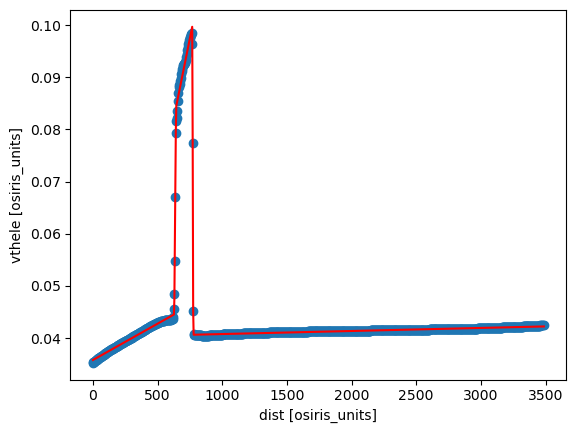

In [13]:
lineout.fit('vthele', degree=5, fit_func="piecewise", plot=True)

0.00044926664066744323


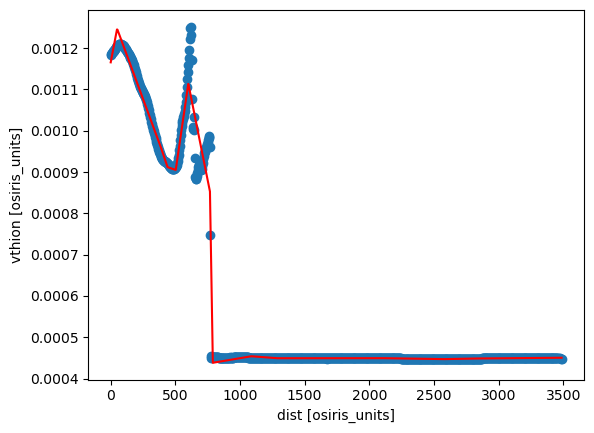

In [22]:
lineout.fit('vthion', degree=13, fit_func="piecewise", plot=True)
print(lineout.get_upstream_value('vthion'))

eyeballing the downstream ion temperature in osiris units to be 

'if(x2 < 2.2442e+00, x2*(-2.2129e-05) + (-1.2642e-04), if(x2 < 3.1635e+02, x2*(8.2392e-07) + (-1.7793e-04), if(x2 < 5.6010e+02, x2*(-2.4137e-06) + (8.4627e-04), if(x2 < 6.1915e+02, x2*(6.48e-05) + (-3.6800e-02), if(x2 < 6.4965e+02, x2*(-1.8330e-04) + (1.1681e-01), if(x2 < 8.4789e+02, x2*(1.7006e-05) + (-1.3317e-02), if(x2 < 2.4471e+03, x2*(9.3221e-08) + (1.0226e-03), if(x2 < 2.6541e+03, x2*(-7.9355e-08) + (1.4449e-03), if(x2 < 3.1221e+03, x2*(1.1275e-07) + (9.3502e-04), if(x2 < 3.4872e+03, x2*(1.5928e-07) + (7.8975e-04), 0.0007897458263147138))))))))))'

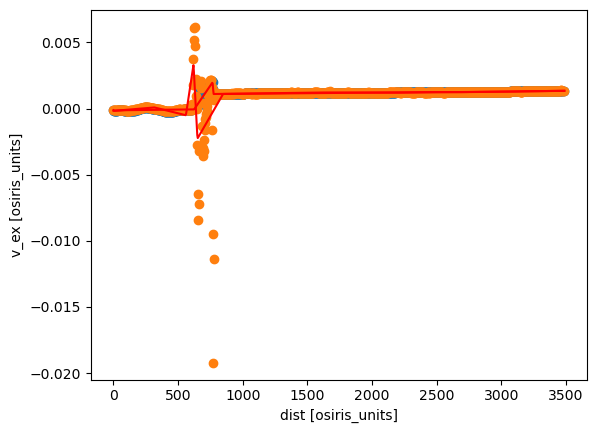

In [ ]:
lineout.fit('v_ix', degree=10, fit_func="piecewise", plot=True)
lineout.fit('v_ex', degree=10, fit_func="piecewise", plot=True)

'if(x2 < 3.8778e+02, x2*(2.00047e-07) + (8.21411e-05), if(x2 < 4.03732e+02, x2*(-1.33787e-04) + (5.20394e-02), if(x2 < 4.24952e+02, x2*(1.33873e-04) + (-5.60236e-02), if(x2 < 5.48231e+02, x2*(-1.03316e-05) + (5.25665e-03), if(x2 < 5.61554e+02, x2*(2.89032e-04) + (-1.58864e-01), if(x2 < 5.9015e+02, x2*(-1.18362e-04) + (6.99099e-02), if(x2 < 8.78896e+02, x2*(-2.0678e-07) + (1.80721e-04), if(x2 < 1.03047e+03, x2*(1.40106e-07) + (-1.24156e-04), if(x2 < 1.09465e+03, x2*(-7.30186e-09) + (2.77433e-05), if(x2 < 1.34491e+03, x2*(5.36096e-09) + (1.3882e-05), 1.3881998890217663e-05))))))))))'

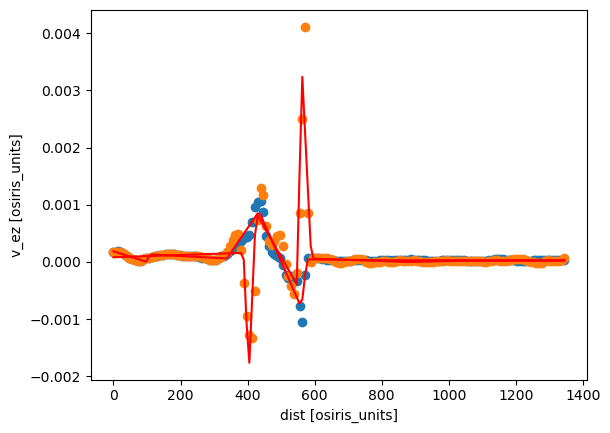

In [10]:
lineout.fit('v_iz', degree=10, fit_func="piecewise", plot=True)
lineout.fit('v_ez', degree=10, fit_func="piecewise", plot=True)

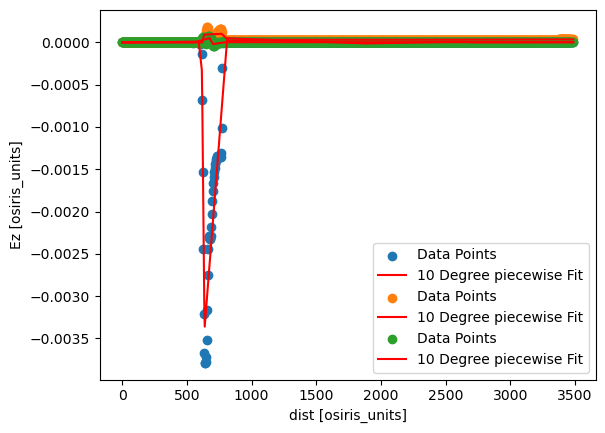

In [19]:
lineout.fit('Ex', degree=10, fit_func="piecewise", plot=True)
lineout.fit('Ey', degree=10, fit_func="piecewise", plot=True)
lineout.fit('Ez', degree=10, fit_func="piecewise", plot=True)
plt.legend()

'if(x2 < 6.1555e+02, x2*(4.108e-07) + (-1.1895e-05), if(x2 < 6.3184e+02, x2*(1.1192e-02) + (-6.8892e+00), if(x2 < 6.4942e+02, x2*(1.1605e-04) + (1.0915e-01), if(x2 < 6.6423e+02, x2*(-4.5109e-03) + (3.114e+00), if(x2 < 6.8317e+02, x2*(2.3493e-04) + (-3.8343e-02), if(x2 < 7.1658e+02, x2*(-1.2342e-03) + (9.6533e-01), if(x2 < 7.6579e+02, x2*(-1.0322e-04) + (1.5488e-01), if(x2 < 7.7321e+02, x2*(-7.0021e-03) + (5.438e+00), if(x2 < 2.7207e+03, x2*(4.6661e-07) + (2.3530e-02), if(x2 < 3.4872e+03, x2*(-8.0291e-07) + (2.6984e-02), 0.026984304741783968))))))))))'

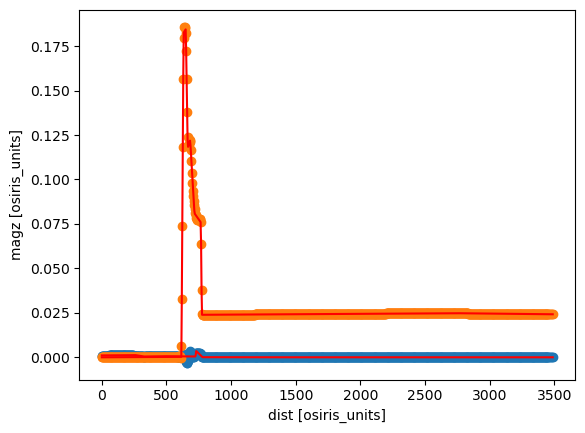

In [18]:
lineout.fit('magy', degree=10, fit_func="piecewise", plot=True)
lineout.fit('magz', degree=10, fit_func="piecewise", plot=True)
plt.legend()